# Global AI Job Market Trends & Salary Insights - Data Visualization


In [33]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('/content/ai_job_dataset.csv')
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [35]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

### **Visualization Project Overview**

Data visualization plays an important role in transforming raw data into meaningful insights. In this project, various visual techniques are used to explore the Global AI Job Market & Salary Insights 2025 dataset and present key trends in a clear and engaging way.

The visualizations focus on salary patterns, remote work adoption, company characteristics, hiring quality, and factors influencing high-paying AI careers. The goal is to create a visual story that helps students, job seekers, recruiters, and organizations better understand the current AI employment landscape and support data-driven decision making.


### **How Do Experience Level and Company Size Influence AI Salaries?**

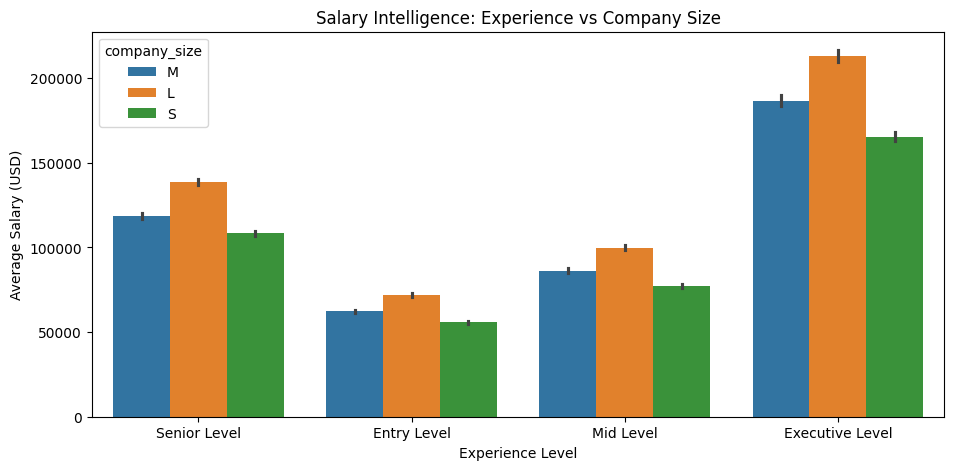

In [36]:
plt.figure(figsize=(11,5))

experience_labels = {
    'EN': 'Entry Level',
    'MI': 'Mid Level',
    'SE': 'Senior Level',
    'EX': 'Executive Level'
}

temp_df = df.copy()
temp_df['experience_level'] = temp_df['experience_level'].map(experience_labels)

sns.barplot(
    x='experience_level',
    y='salary_usd',
    hue='company_size',
    data=temp_df,
    estimator=np.mean
)

plt.title("Salary Intelligence: Experience vs Company Size")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.show()

#### Visual Insight

The heatmap shows a clear relationship between experience level and salary growth. Executive and senior professionals consistently earn higher salaries across all company sizes, while entry-level positions receive comparatively lower compensation.

Large companies generally offer higher salaries than medium and small organizations, especially for experienced professionals. This highlights the combined impact of experience and company size on earning potential in the AI job market.


### **Which Countries Show the Highest Remote Work Adoption in AI Jobs?**

#### Remote Work Categories

- 0 = Onsite Work
- 50 = Hybrid Work
- 100 = Fully Remote Work

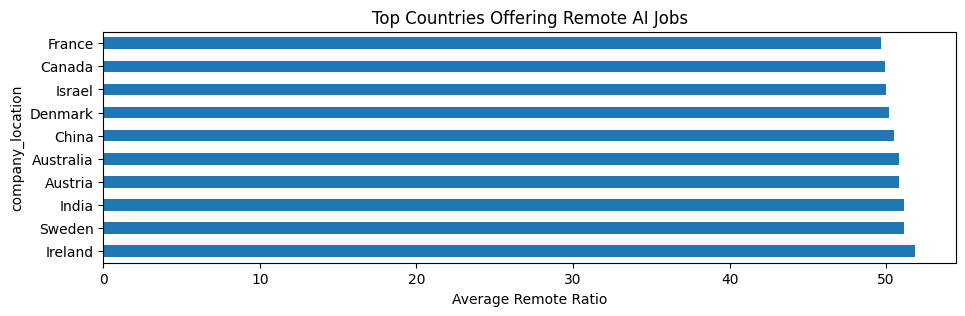

In [37]:
remote_by_country = df.groupby('company_location')['remote_ratio'].mean().sort_values(ascending=False).head(10)

remote_by_country.plot(kind='barh', figsize=(11,3))
plt.title("Top Countries Offering Remote AI Jobs")
plt.xlabel("Average Remote Ratio")
plt.show()

#### Visual Insight

The visualization reveals clear differences in how remote work is adopted across various countries. In some regions, AI professionals are more likely to work in fully remote roles, while in others, hybrid or onsite work remains more common.

This variation indicates that workplace flexibility in the AI industry depends heavily on location. As a result, job seekers may find different levels of remote work opportunities depending on the country in which they choose to work.


### **How Does Salary Grow Across Different Experience Levels in AI Careers?**

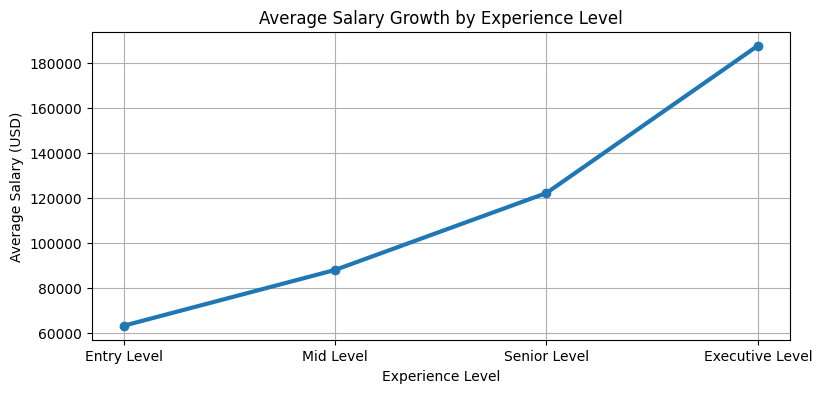

In [38]:
salary_growth = (
    df.groupby('experience_level')['salary_usd']
      .mean()
      .reindex(['EN', 'MI', 'SE', 'EX'])
)

salary_growth.index = [
    'Entry Level',
    'Mid Level',
    'Senior Level',
    'Executive Level'
]

plt.figure(figsize=(9,4))

plt.plot(
    salary_growth.index,
    salary_growth.values,
    marker='o',
    linewidth=3
)

plt.title('Average Salary Growth by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')

plt.grid(True)

plt.show()

#### Visual Insight
The chart reveals a strong positive relationship between experience and salary in AI careers. Compensation increases consistently as professionals move from entry-level positions to senior and executive roles.

The sharp rise in salary at higher experience levels highlights the long-term value of skill development, industry expertise, and leadership responsibilities in the AI job market.


### **What Makes an AI Job More Attractive to Candidates?**

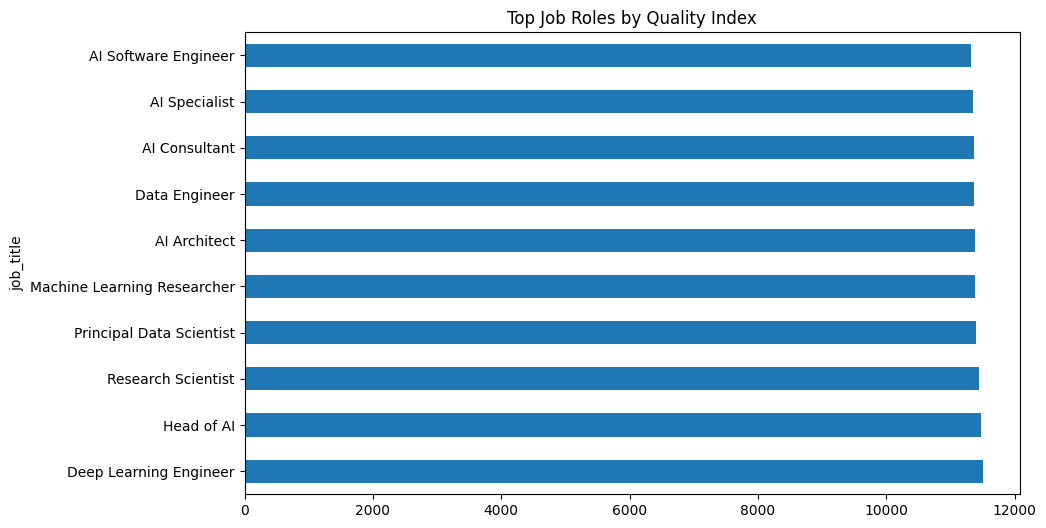

In [39]:
df['job_quality_index'] = df['job_description_length'] * df['benefits_score']

top_jobs = df.groupby('job_title')['job_quality_index'].mean().sort_values(ascending=False).head(10)

top_jobs.plot(kind='barh', figsize=(10,6))
plt.title("Top Job Roles by Quality Index")
plt.show()

#### Visual Insight

This visualization shows that salary is not the only factor that makes an AI job attractive. Benefits, flexibility, and skill requirements also play an important role in shaping job opportunities.

Jobs that offer a balanced combination of these factors are likely to be more appealing to candidates, highlighting the importance of overall job value rather than compensation alone.


### **High Salary Career Blueprint**
### What Factors Contribute to High-Paying AI Careers?

In [40]:
# High Salary Group

high_salary_threshold = df['salary_usd'].quantile(0.80)
high_salary_df = df[df['salary_usd'] >= high_salary_threshold]
high_salary_df.shape

(3000, 20)

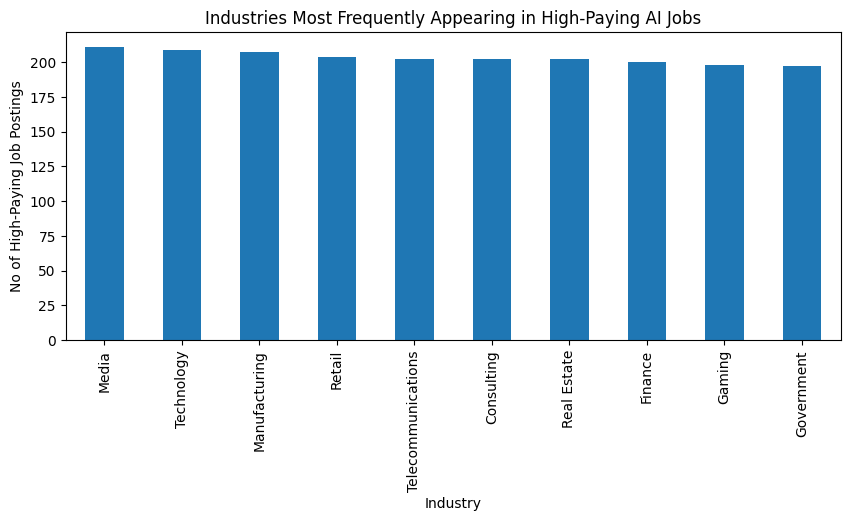

In [41]:
# Industries in High Salary Jobs

high_salary_df['industry'].value_counts().head(10).plot(kind='bar', figsize=(10,4))
plt.title("Industries Most Frequently Appearing in High-Paying AI Jobs")
plt.xlabel("Industry")
plt.ylabel("No of High-Paying Job Postings")
plt.show()

#### Observation
This chart shows which industries have the highest number of jobs among the top-paying AI positions.

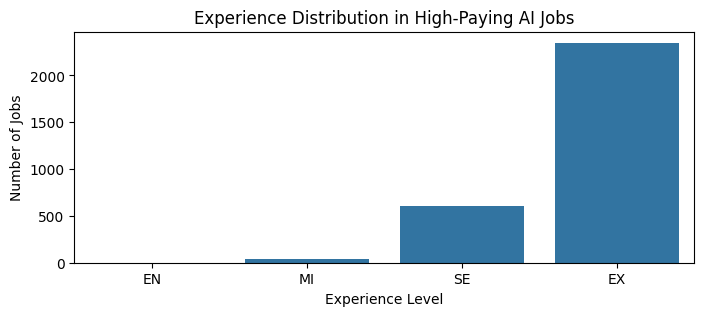

In [42]:
# Experience distribution in high salary jobs

order = ['EN', 'MI', 'SE', 'EX']

plt.figure(figsize=(8,3))
sns.countplot(
    x='experience_level',
    data=high_salary_df,
    order=order
)

plt.title("Experience Distribution in High-Paying AI Jobs")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.show()

#### Observation
This chart examines the experience levels most commonly found in high-paying AI positions.

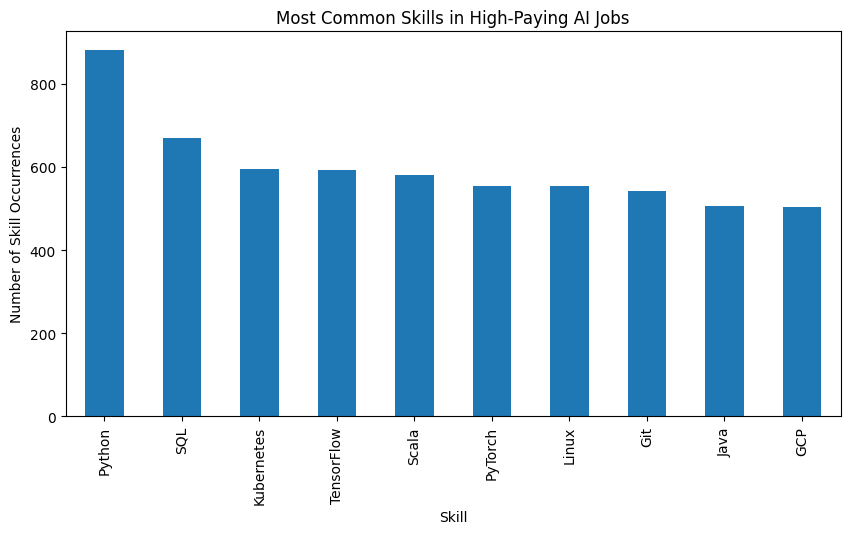

In [43]:
# Skills analysis in high paying jobs

skills_high = high_salary_df['required_skills'].str.split(',').explode().str.strip()
top_high_skills = skills_high.value_counts().head(10)

top_high_skills.plot(kind='bar', figsize=(10,5))
plt.title("Most Common Skills in High-Paying AI Jobs")
plt.xlabel("Skill")
plt.ylabel("Number of Skill Occurrences")
plt.show()

#### Observation
This chart highlights the skills that are most frequently required in high-paying AI roles.

#### Visual Insight
The analysis shows that high-paying AI roles are influenced by a combination of industry demand, professional experience, and technical expertise. Certain industries contribute a larger share of high-salary opportunities, while experienced professionals are more commonly represented in top-paying positions.

The skill analysis further highlights that in-demand technical skills are frequently associated with higher-paying roles. Overall, the findings suggest that long-term success in the AI field depends on continuously developing valuable skills, gaining practical experience, and targeting industries with strong investment in AI technologies.



### **Key Visual Findings**

* AI salaries increase significantly as professionals gain more experience, with senior and executive roles receiving the highest compensation.
* Remote work opportunities are distributed across different countries, showing that AI hiring practices vary globally.
* Attractive AI jobs are influenced by multiple factors, including benefits, work flexibility, and skill requirements, rather than salary alone.
* High-paying AI roles are available across several industries, indicating that strong career opportunities exist beyond traditional technology companies.
* Technical skills, industry demand, and professional experience collectively contribute to long-term career growth and higher earning potential in the AI field.


### **Conclusion**

Working on this project gave me a better understanding of the AI job market and the factors that influence career opportunities in this field. By analyzing salary trends, experience levels, remote work patterns, and job requirements, I was able to identify several meaningful insights from the data.

The results suggest that experience, in-demand skills, and industry demand all play an important role in shaping salary outcomes. At the same time, benefits and workplace flexibility also contribute to making a job more attractive to professionals.

Overall, this project highlights how data visualization can be used to uncover trends, support decision-making, and communicate complex information in a simple and effective way.
